# lattice

In [1]:
import crypy as cp
import numpy as np
from matplotlib import pyplot as plt
from crypy_examples.atom_network import (
    draw_atom, 
    draw_bond,
    color_bond,
    r_Se,
    r_Ta,
    r_bond,
    a1,a2,
    p1,p2,p3,p4        
)
from matplotlib.colors import to_rgb
from crypy_examples.colorspace import CLR_NODE
# region Fundamental Parameters
xylim = ((-10,10),(-10,10))


color_Se_HA = [254,164,0]
color_Ta_HA = [0, 176, 240]
color_Se_vesta = [202,137,33]
color_Ta_vesta = [38,115,148]
hexer =  lambda rgb: '#{:02x}{:02x}{:02x}'.format(*rgb)
# endregion

# region class setup for figure
# region LEVEL 1: ATOMIC LATTICE
pv = cp.PrimitiveVector2D(a1,a2)
bss = cp.Basis2D(pv)
# gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)

alpha_common = .3
def gen_cation_triangle(x,y):
    return cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r = 1/np.sqrt(3),alpha=alpha_common,
        c=CLR_NODE[1],phi=-np.pi/6
        )
def gen_anion_triangle(x,y):
    return cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r = 1/np.sqrt(3),alpha=alpha_common,
        c=CLR_NODE[0],phi=np.pi/6
        )
# gen_triangle = lambda x,y: cp.Collection.Generator.gen_regular_polygon(3,x=x,y=y,r = 1)
gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
gen_bond = lambda x,y: draw_bond(x,y,r=r_bond*.6,facecolor=to_rgb(color_bond))

print("color_bond rgb:",to_rgb(color_bond))
bss.add_artist(gen_bond,(p1,p2),label = 'bond1')
bss.add_artist(gen_bond,(p1,p3),label = 'bond2')
bss.add_artist(gen_bond,(p2,p4),label = 'bond3')
bss.add_artist(gen_atom_Ta,(p1),label='Ta')
bss.add_artist(gen_atom_Se,(p2),label='Se')
# bss.add_artist(gen_cation_hexagon,(p1),label='cation_hexagon')
# bss.add_artist(gen_anion_hexagon,(p2),label='anion_hexagon')
# bss.add_artist(gen_cation_triangle,(p1),label='cation_triangle')
# bss.add_artist(gen_anion_triangle,(p2),label='anion_triangle')

# bss.add_artist(gen_triangle,(p2),label='triangle')

lp = cp.LatticePoints2D(pv) 
lp.generate_points_by_xylim(*xylim)
cry = cp.Crystal2D(bss,lp)
# endregion



# region LEVEL 2: CDW 
pv_sup = pv.get_super_structure(3,3)
bss_sup = cp.Basis2D(pv_sup)
gen_CDW = lambda xxx,yyy: plt.fill(xxx,yyy,"y",alpha=.3)
cdw_p1 = np.array((2/3,1/3))
cdw_p2 = np.array((-1/3,1/3))
cdw_p3 = np.array((-1/3,-2/3))
cdw_ps = np.array((cdw_p1,cdw_p2,cdw_p3)) + np.array((1/3,0)).reshape(1,2)

bss_sup.add_artist(gen_CDW,cdw_ps,label='CDW')
lp_sup = cp.LatticePoints2D(pv_sup)   
lp_sup.generate_points_by_xylim(*xylim)
cry_sup = cp.Crystal2D(bss_sup,lp_sup)
gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
gen_wigner = lambda x,y: cp.Collection.Generator.gen_hexagon(
    x=x,y=y,r=3*1/np.sqrt(3),alpha=.3,phi=np.pi/2,facecolor='none',edgecolor='m',lw=1)
bss_wigner = cp.Basis2D(pv_sup)
bss_wigner.add_artist(gen_wigner,(0,0),label='wigner')
cry_sup_wigner = cp.Crystal2D(bss_wigner,lp_sup)

# endregion
# endregion

# region plot

# endregion
    
cry._basis.add_artist(gen_cation_triangle,(p1),label='cation_triangle')
cry._basis.add_artist(gen_anion_triangle,(p2),label='anion_triangle')

color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)


In [2]:
import copy
cry_lattice = copy.deepcopy(cry)
cry_vortex_triangle = copy.deepcopy(cry)
cry_lattice._basis._artist_list = cry_lattice._basis._artist_list[:-2]
cry_vortex_triangle._basis._artist_list = cry_vortex_triangle._basis._artist_list[-2:]

(-1.0, 1.0)

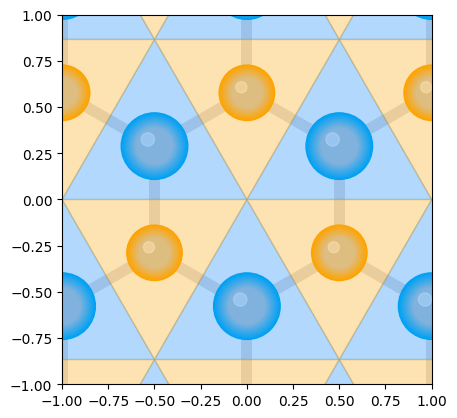

In [3]:
# 
# cry._basis._artist_list=cry._basis._artist_list[:-1]
fig,ax =cry.plot_crystal()
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)

# Words and Trajector

In [29]:
def draw_cyclic_arrows(n, colors=None, reverse=None, radius=1):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Set default colors
    if colors is None:
        colors = ['black'] * n
    elif len(colors) != n:
        raise ValueError(f"colors must have length {n}")
    
    # Set arrow directions
    if reverse is None:
        reverse = [False] * n
    elif len(reverse) != n:
        raise ValueError(f"reverse must have length {n}")
    
    # Compute vertices of the n-gon
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    vertices = np.array([[radius*np.cos(angle), radius*np.sin(angle)] for angle in angles])
    
    # Draw arrows between consecutive vertices
    for i in range(n):
        if reverse[i]:
            # Reverse arrow direction
            start = vertices[(i+1) % n]
            end = vertices[i]
        else:
            # Default arrow direction
            start = vertices[i]
            end = vertices[(i+1) % n]
        
        # Vector from start to end
        dx = end[0] - start[0]
        dy = end[1] - start[1]
        
        ax.arrow(start[0], start[1], dx, dy, 
                 width=0.05, color=colors[i], length_includes_head=True, 
                 overhang=0.3, head_width=0.15, head_length=0.4)
    
    ax.set_xlim(-radius-0.5, radius+0.5)
    ax.set_ylim(-radius-0.5, radius+0.5)
    ax.set_aspect('equal')
    ax.set_title(f'{n}-gon with cyclic arrows', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.show()
def draw_arrow_trajectory(drs, clrs, show_origin=True, index_points=False, index_arrows=False, text_kwargs=None, xy_origin=(0.0, 0.0)):
    ''' 
    Args
        drs(array): list of direction vectors (dx, dy)
        clrs(n length): list of colors for each arrow
        show_origin(bool): mark the origin (xy_origin)
        index_points(bool): label trajectory points 0..n-1 (start points)
        index_arrows(bool): label arrows 1..n at their midpoints
        text_kwargs(dict): passed to ax.text for styling
        xy_origin(tuple): (x,y) coordinates for the starting origin (default (0,0))
    '''
    import matplotlib.patheffects as path_effects
    drs = np.asarray(drs, dtype=float)
    if drs.ndim != 2 or drs.shape[1] != 2:
        raise ValueError("drs must be an array-like of shape (n, 2)")
    
    n = drs.shape[0]
    if len(clrs) != n:
        raise ValueError("clrs must have the same length as drs")
    
    if text_kwargs is None:
        text_kwargs = dict(color='black', fontsize=10, va='center', ha='center', backgroundcolor=(0, 0, 0, 0), alpha=1, clip_on=True)
    
    fig = plt.gcf()
    ax = plt.gca()
    origin = np.asarray(xy_origin, dtype=float)
    if origin.shape != (2,):
        raise ValueError("xy_origin must be a length-2 sequence (x, y)")
    points = np.zeros((n + 1, 2))
    points[0] = origin
    text_objs = {"points": [], "arrows": []}
    offset = 0.08  # small offset for text placement

    for i, (dx, dy) in enumerate(drs):
        start = points[i]
        ax.arrow(
            start[0], start[1], dx, dy,
            width=0.1,
            length_includes_head=True,
            head_width=0.4,
            head_length=0.4,
            color=clrs[i]
        )
        # label start point if requested (0..n-1)
        if index_points:
            end_ = start + np.array((dx, dy))
            txt = ax.text(end_[0] - offset, end_[1] - offset, str(i+1), **text_kwargs)
            text_objs["points"].append(txt)
        # label arrow (1..n) at midpoint if requested
        if index_arrows:
            mid = start + 0.4 * np.array((dx, dy))
            txt = ax.text(mid[0], mid[1], str(i + 1), **text_kwargs)
            txt.set_path_effects([
                path_effects.withStroke(linewidth=3, foreground='white')
            ])
            text_objs["arrows"].append(txt)
        points[i + 1] = start + np.array((dx, dy))
    
    # mark origin if requested
    if show_origin:
        origin_marker, = ax.plot(origin[0], origin[1], marker='o', color='k', markersize=5)
    
    margin = 0.5
    xmin, xmax = points[:, 0].min() - margin, points[:, 0].max() + margin
    ymin, ymax = points[:, 1].min() - margin, points[:, 1].max() + margin
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    return fig, ax, text_objs
def gen_tex_boundary_words(word, is_color=False):
    '''for given integer list, generate LaTeX code for boundary words.
    1->r, 2->g, 3->b, -1->r^{-1}, -2->g^{-1}, -3->b^{-1}
    Args:
        word (list of int): A list of integers representing the boundary word.\pm(1,2,3)
        is_color (bool): If True, wrap r/g/b in \textcolor{...}{...} for LaTeX coloring.
    Returns:
        str: A string containing the LaTeX code for the boundary word.
    '''
    mapping = {
        1: r'r',
        2: r'g',
        3: r'b',
        -1: r'r^{-1}',
        -2: r'g^{-1}',
        -3: r'b^{-1}',
    }
    color_map = {
        1: 'red',
        2: 'green',
        3: 'blue'
    }

    def fmt(x):
        key = int(x)
        base = mapping[key]
        if is_color:
            c = color_map[abs(key)]
            return rf'\textcolor{{{c}}}{{{base}}}'
        return base

    try:
        return ' '.join(fmt(x) for x in word)
    except (TypeError, ValueError, KeyError):
        raise ValueError("word must be an iterable of integers in [-3, -2, -1, 1, 2, 3]")

class RgbBoundary():
    ALLOWED_VALUES = [1,2,3,-1,-2,-3]
    COLOR = ["red","green","blue"]
    THETAS = np.array([3,1,-1])*np.pi/3
    def __init__(self,word):
        self._word = np.array(word)
        if not self._validate():
            raise ValueError("Invalid word for rgbBoundary.")
        print(self.map_to_one_hot_sign().sum(axis=0))
        if self.is_z3z3_identity():
            print("The word represents the identity element in Z3 x Z3.")
        if self.is_vortex_decomposable():
            print("The word is vortex decomposable.")

    def _validate(self):
        if self._word.size == 0:
            return False
        return np.isin(self._word,self.ALLOWED_VALUES).all()
    def is_vortex_decomposable(self):
        exponent = self.map_to_one_hot_sign().sum(axis=0)
        return (exponent == 0).all()
    def is_z3z3_identity(self):
        exponent = self.map_to_one_hot_sign().sum(axis=0)
        exponent_mod_3 = exponent % 3
        return (exponent_mod_3 == 0).all()
    def map_to_one_hot_sign(self):
        # Convert input to a numpy array seamlessly
        arr = self._word
        n = arr.size

        # Initialize an (n, 3) array filled with zeros
        result = np.zeros((n, 3), dtype=int)

        if n == 0:
            return result
            
        # Calculate the column indices: abs(val) - 1 maps (1, 2, 3) to (0, 1, 2)
        col_indices = np.abs(arr) - 1

        # Calculate the signs: 1 for positive, -1 for negative numbers
        signs = np.sign(arr)

        # Use advanced indexing to place the signs into the correct positions
        # np.arange(n) targets each row, and col_indices targets the correct column
        result[np.arange(n), col_indices] = signs

        return result
    def draw_arrow_trajectory(self,**kwargs):
        drs = []
        for val in self._word:
            tht = self.THETAS[abs(val)-1]
            sign = 1 if val > 0 else -1
            dr = np.array([np.cos(tht), np.sin(tht)]) * sign
            drs.append(dr)
        clrs = [self.COLOR[(abs(val)-1) % 3] for val in self._word]
        fig, ax, text_objs = draw_arrow_trajectory(drs, clrs, **kwargs)
        # If point indexing requested, relabel start points so they read 1..n with the 0th shown as n
        # if kwargs.get('index_points', False):
        #     pts = text_objs.get("points", [])
        #     m = len(pts)
        #     for j, txt in enumerate(pts):
        #     lbl = str(j) if j > 0 else str(m)
        #     txt.set_text(lbl)
        # return fig, ax, text_objs
    def draw_cyclic_arrows(self):
        return draw_cyclic_arrows(len(self._word), [self.COLOR[(abs(val)-1) % 3] for val in self._word], [val < 0 for val in self._word], 1)
    def gen_boundary_word_tex(self, is_color=False):
        return gen_tex_boundary_words(self._word, is_color=is_color)

<>:117: SyntaxWarning: invalid escape sequence '\p'
<>:117: SyntaxWarning: invalid escape sequence '\p'
C:\Users\user\AppData\Local\Temp\ipykernel_42992\840036443.py:117: SyntaxWarning: invalid escape sequence '\p'
  '''for given integer list, generate LaTeX code for boundary words.


[0 0 0]
The word represents the identity element in Z3 x Z3.
The word is vortex decomposable.
[1 1 1]
[-1 -1 -1]
[3 0 0]
The word represents the identity element in Z3 x Z3.
[1 2 0]


(-4.0, 4.0)

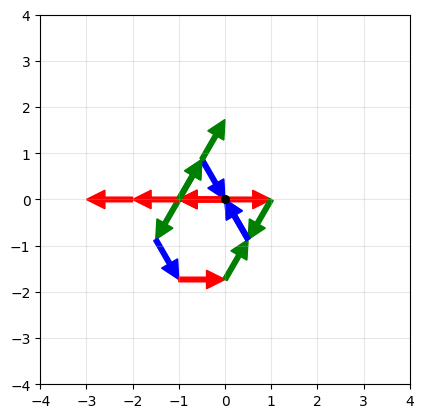

In [5]:
# fig,ax  = cry.plot_crystal()

RgbBoundary([1,-2,3,-1,2,-3]).draw_arrow_trajectory()
RgbBoundary([1,2,3]).draw_arrow_trajectory()
RgbBoundary([-1,-2,-3]).draw_arrow_trajectory()
RgbBoundary([1,1,1]).draw_arrow_trajectory()
RgbBoundary([1,2,2]).draw_arrow_trajectory()
ax = plt.gca()
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)

# Publish Graphic

In [6]:
words = [
    [1,2,3],
    [-1,-2,-3],
    [1,2,1,2],
    [1,1,1],
    [-3,-2,-1],
    [1,2,-1,-2],
    [1,1,1,2,2,2,3,3,3],
    [1,2,1,2,2,2,3,-2,3,3,1],
    [-2,1,2,2,2,3,-2] 
]

## Extend scheme

C:\Users\user\AppData\Local\Temp\ipykernel_42992\4290096850.py:5: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0, left=0, right=0, top=0, bottom=0)


[1 1 1]
[-1 -1 -1]
[2 2 0]
[3 0 0]
The word represents the identity element in Z3 x Z3.
[-1 -1 -1]
[0 0 0]
The word represents the identity element in Z3 x Z3.
The word is vortex decomposable.
[3 3 3]
The word represents the identity element in Z3 x Z3.
[3 3 3]
The word represents the identity element in Z3 x Z3.
[1 1 1]


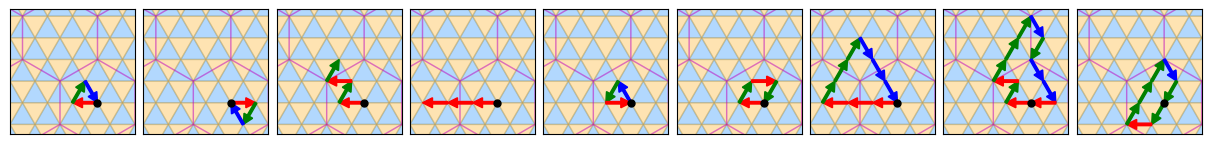

In [7]:
# words = words[:5]
nsb = len(words)
ind = 0
fig, axs = plt.subplots(1, nsb, figsize=(12, 8), constrained_layout=True)
fig.subplots_adjust(wspace=0, left=0, right=0, top=0, bottom=0)

for word in words:
    ind += 1
    ax = axs[ind-1]
    plt.sca(ax)
    fig,ax  = cry_vortex_triangle.plot_crystal()
    cry_sup_wigner.plot_crystal()
    
    
    # ax.set_position([0,0,1,1])

    RgbBoundary(word).draw_arrow_trajectory(index_points=False,show_origin=True,index_arrows=False)
    ax.set_xticks([])
    ax.set_yticks([])
    # ax.set_xlim(-2,2)
    # ax.set_ylim(-2,2)
    ax.set_xlim(-3.5,1.5)
    ax.set_ylim(-1.25,3.75)

In [8]:
fig.savefig("assets/E06_boundary_examples.svg")

## Folded Scheme

In [9]:
import numpy as np
import matplotlib.patches as patches
from matplotlib.path import Path
from shapely.geometry import Polygon, box

def get_subtracted_patch():
    """
    Creates a square and a regular hexagon using Shapely, performs a subtraction
    (Square - Hexagon), and returns the result as a Matplotlib PathPatch object.
    
    Returns:
        patches.PathPatch: The subtracted patch object with a hole in the center.
    """
    # 1. Create a Shapely geometry for the Square
    square_geom = box(-5, -5, 5, 5)

    # 2. Create a Shapely geometry for the Regular Hexagon
    hex_radius = np.sqrt(3)
    num_sides = 6
    angles = np.linspace(0, 2 * np.pi, num_sides, endpoint=False) + np.pi / 2
    hex_vertices = [(hex_radius * np.cos(a), hex_radius * np.sin(a)) for a in angles]
    hexagon_geom = Polygon(hex_vertices)

    # 3. Perform the subtraction (Square - Hexagon)
    result_geom = square_geom.difference(hexagon_geom)

    # 4. Convert the Shapely result into a Matplotlib PathPatch
    if result_geom.geom_type == 'Polygon':
        ext_vertices = np.array(result_geom.exterior.coords)
        
        # Initialize lists for vertices and path codes
        all_vertices = [ext_vertices]
        all_codes = [[Path.MOVETO] + [Path.LINETO] * (len(ext_vertices) - 2) + [Path.CLOSEPOLY]]
        
        # Process interior holes (the hexagon part)
        for interior in result_geom.interiors:
            int_vertices = np.array(interior.coords)
            all_vertices.append(int_vertices)
            all_codes.append([Path.MOVETO] + [Path.LINETO] * (len(int_vertices) - 2) + [Path.CLOSEPOLY])
        
        # Merge all components into single numpy arrays
        vertices = np.concatenate(all_vertices)
        codes = np.concatenate(all_codes)
        
        # Create the final Matplotlib PathPatch object
        subtracted_path = Path(vertices, codes)
        subtracted_patch = patches.PathPatch(
            subtracted_path,
            linewidth=2,
            edgecolor='blue',
            facecolor='lightblue',
            alpha=1,
            zorder=1000000,
            label='Square - Hexagon'
        )
        return subtracted_patch
        
    return None

C:\Users\user\AppData\Local\Temp\ipykernel_42992\3311985166.py:5: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0, left=0, right=0, top=0, bottom=0)


[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[2 2 0]
[2 2 0]
[2 2 0]
[2 2 0]
[2 2 0]
[2 2 0]
[2 2 0]
[2 2 0]
[2 2 0]
[3 0 0]
The word represents the identity element in Z3 x Z3.
[3 0 0]
The word represents the identity element in Z3 x Z3.
[3 0 0]
The word represents the identity element in Z3 x Z3.
[3 0 0]
The word represents the identity element in Z3 x Z3.
[3 0 0]
The word represents the identity element in Z3 x Z3.
[3 0 0]
The word represents the identity element in Z3 x Z3.
[3 0 0]
The word represents the identity element in Z3 x Z3.
[3 0 0]
The word represents the identity element in Z3 x Z3.
[3 0 0]
The word represents the identity element in Z3 x Z3.
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[-1 -1 -1]
[0 0 0]
The word represents the identity element in Z3 x Z3.
The word is vortex decomposable.
[0 0 0]
The wor

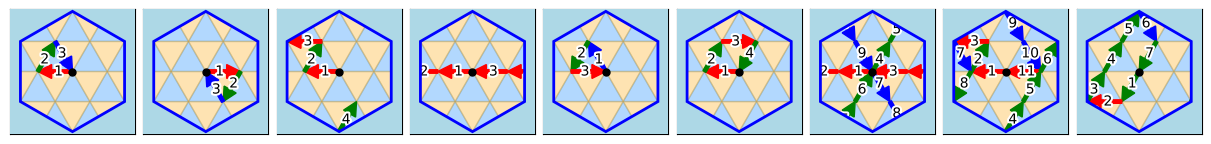

In [10]:
# words = words[:5]
nsb = len(words)
ind = 0
fig, axs = plt.subplots(1, nsb, figsize=(12, 3), constrained_layout=True)
fig.subplots_adjust(wspace=0, left=0, right=0, top=0, bottom=0)

crop = 1.8
for word in words:
    ind += 1
    ax = axs[ind-1]
    plt.sca(ax)
    fig,ax  = cry_vortex_triangle.plot_crystal()
    cry_sup_wigner.plot_crystal()
    for a1s in [0,1,-1]:
        for a2s in [0,1,-1]:
            xy_origin = a1s*pv_sup.a1 + a2s*pv_sup.a2
            RgbBoundary(word).draw_arrow_trajectory(index_points=False,show_origin=True,index_arrows=True,
                                                    xy_origin=xy_origin)
            ax.set_xticks([])
    ax.set_yticks([])    
    ax.set_xlim(-crop,crop)
    ax.set_ylim(-crop,crop)
    ax.add_patch(get_subtracted_patch())
    
    
    # ax.set_position([0,0,1,1])


# ax.set_xlim(-2,2)
# ax.set_ylim(-2,2)
# ax.set_xlim(-4,4)
# ax.set_ylim(-4,4)

In [11]:
fig.savefig("assets/E06_boundary_examples_reduced.svg")

# publish text

In [31]:
word = words[-1]
obj = RgbBoundary(word)

[1 1 1]


## boundary

In [32]:
obj.gen_boundary_word_tex()

'g^{-1} r g g g b g^{-1}'

## Phase trajectory, Accumulated phase

In [44]:
mat = obj.map_to_one_hot_sign()
L = np.array([[1,0,-1],[0,1,-1]])
mat_proj = L @ mat.T
mat_traj =np.cumsum(mat_proj, axis=1)
mat_traj_mod = (mat_traj+1) % 3 -1
print(mat_traj_mod)


[[ 0  1  1  1  1  0  0]
 [-1 -1  0  1 -1  1  0]]


## Group Reduction, Heisenberg Matrix

In [46]:
from sympy import symbols,Matrix, simplify, N,re,im,I
def M(a, b, c):
    return Matrix([[1, a, c], [0, 1, b], [0, 0, 1]])
r = M(1,0,0)
g = M(0,1,0)
b = M(-1,-1,1/2+(1/2)*I)
q_C = r*g*b
q_A = r.inv()*g.inv()*b.inv()

In [57]:
def check_cZ(mat, tol=1e-9):
    # 1) Check if mat is (3,3)
    try:
        if hasattr(mat, 'shape'):
            shape = mat.shape
        else:
            mat = np.array(mat)
            shape = mat.shape

        if shape != (3, 3): return False
    except:
        return False

    # For SymPy matrices, use N() for numerical evaluation; for NumPy, use directly
    def get_val(r, c):
        val = mat[r, c]
        try:
            return float(N(val)) if hasattr(val, 'evalf') else float(val)
        except TypeError: # If symbols remain, float conversion is not possible
            return val

    # 2) Check if diagonal elements are 1 (|val - 1| < tol)
    for i in range(3):
        val = get_val(i, i)
        if isinstance(val, float):
            if abs(val - 1.0) > tol: return False
        elif val != 1: return False # Strict comparison for symbolic cases

    # 3) Check if all elements except diagonal and (0,2) are 0 (|val| < tol)
    zero_positions = [(0, 1), (1, 0), (1, 2), (2, 0), (2, 1)]
    for r, c in zero_positions:
        val = get_val(r, c)
        if isinstance(val, float):
            if abs(val) > tol: return False
        elif val != 0: return False

    # If all conditions are met, return element (0,2)
    return mat[0, 2]
def get_nCA(q):
  n_C = re(q)+im(q)
  n_A = re(q)-im(q)
  return n_C,n_A
from toolz import compose
check_nCA = compose(get_nCA,check_cZ)

In [51]:
abs(3)

3

In [ ]:
word
accum_mul = 1
mats =[r,g,b]
for char in word:
    sgn = np.sign(char)
    val = abs(char)
    mat_now = mats[val-1] if sgn > 0 else mats[val-1].inv()
    accum_mul = accum_mul * mat_now

In [54]:
def heisenberg_product(word):
    accum_mul = 1
    mats = [r, g, b]
    for char in word:
        sgn = np.sign(char)
        val = abs(char)
        mat_now = mats[val-1] if sgn > 0 else mats[val-1].inv()
        accum_mul = accum_mul * mat_now
    return accum_mul

In [58]:
q = heisenberg_product(word)
check_nCA(q)

(3.00000000000000, 2.00000000000000)